# Comprensión y Análisis Exploratorio de Datos (EDA)
## Proyecto: Modelo de Riesgo Crediticio — PIM5

Este notebook desarrolla la exploración inicial y el análisis exploratorio de datos (EDA) sobre la base de créditos, como parte del Avance 1 del Proyecto Integrador.

**Objetivo:** entender la estructura, calidad y relaciones de los datos antes de construir el modelo predictivo de comportamiento de pago (`Pago_atiempo`).

In [ ]:
import sys
import os

# Permite importar cargar_datos.py sin duplicar la lógica de carga
sys.path.append(os.path.abspath('.'))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from Mlops_Pipeline.src.cargar_datos import cargarDatos

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Exploración inicial de datos

In [23]:
df = cargarDatos()
df.shape

       tipo_credito      fecha_prestamo  capital_prestado  plazo_meses  \
0                 7 2024-12-21 11:31:35         3692160.0           10   
1                 4 2025-04-22 09:47:35          840000.0            6   
2                 9 2026-01-08 12:22:40         5974028.4           10   
3                 4 2025-08-04 12:04:10         1671240.0            6   
4                 9 2025-04-26 11:24:26         2781636.0           11   
...             ...                 ...               ...          ...   
10758             9 2025-01-19 16:18:28         2414886.0           10   
10759             4 2025-01-10 16:40:21         2916000.0           24   
10760             4 2025-06-19 14:28:47         4249200.0           36   
10761             9 2025-03-02 11:53:41         1283307.6           10   
10762             4 2024-12-08 12:46:03         3915000.0           12   

       edad_cliente   tipo_laboral  salario_cliente  total_otros_prestamos  \
0                42  Independient

(10763, 23)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvigentes     

In [25]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
tipo_credito,10763.0,NaN,NaN,NaN,5.411131,4.0,4.0,4.0,9.0,68.0,2.338279
fecha_prestamo,10763,NaN,NaN,NaN,2025-04-16 23:06:02.111121,2024-11-26 09:17:04,2025-01-20 17:33:07.500000,2025-03-27 16:23:12,2025-06-16 13:27:58,2026-04-26 18:43:52,NaN
capital_prestado,10763.0,NaN,NaN,NaN,2434315.001319,360000.0,1224831.0,1921920.0,3084840.0,41444152.8,1909642.758997
plazo_meses,10763.0,NaN,NaN,NaN,10.575583,2.0,6.0,10.0,12.0,90.0,6.632082
edad_cliente,10763.0,NaN,NaN,NaN,43.94862,19.0,33.0,42.0,53.0,123.0,15.060877
tipo_laboral,10763,2,Empleado,6754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salario_cliente,10763.0,NaN,NaN,NaN,17216431.459909,0.0,2000000.0,3000000.0,4875808.0,22000000000.0,355476717.603482
total_otros_prestamos,10763.0,NaN,NaN,NaN,6238869.648518,0.0,500000.0,1000000.0,2000000.0,6787675263.0,118418316.941069
cuota_pactada,10763.0,NaN,NaN,NaN,243617.406671,23944.0,121041.5,182863.0,287833.5,3816752.0,210493.694608
puntaje,10763.0,NaN,NaN,NaN,91.170036,-38.00999,95.227787,95.227787,95.227787,95.227787,16.465441


In [26]:
# Duplicados
print("Filas duplicadas:", df.duplicated().sum())

# Nulos por columna
nulos = df.isnull().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]
nulos

Filas duplicadas: 0


tendencia_ingresos               2932
promedio_ingresos_datacredito    2930
saldo_mora_codeudor               590
saldo_principal                   405
saldo_mora                        156
saldo_total                       156
puntaje_datacredito                 6
dtype: int64

**Hallazgos iniciales:**
- Registrar cuántas filas/columnas tiene el dataset y qué representa cada una.
- Las columnas con nulos (`saldo_mora_codeudor`, `promedio_ingresos_datacredito`, `tendencia_ingresos`, `saldo_principal`, `saldo_total`, `saldo_mora`, `puntaje_datacredito`)
- Revisar si `tendencia_ingresos` tiene valores inconsistentes (ver sección de calidad de datos más abajo).

## 2. Análisis univariable

In [27]:
# Separar variables numéricas y categóricas
target = "Pago_atiempo"

col_categoricas = df.select_dtypes(include=["object", "str"]).columns.tolist()
col_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
if target in col_numericas:
    col_numericas.remove(target)

print("Categóricas:", col_categoricas)
print("Numéricas:", col_numericas)

Categóricas: ['tipo_laboral', 'tendencia_ingresos']
Numéricas: ['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']


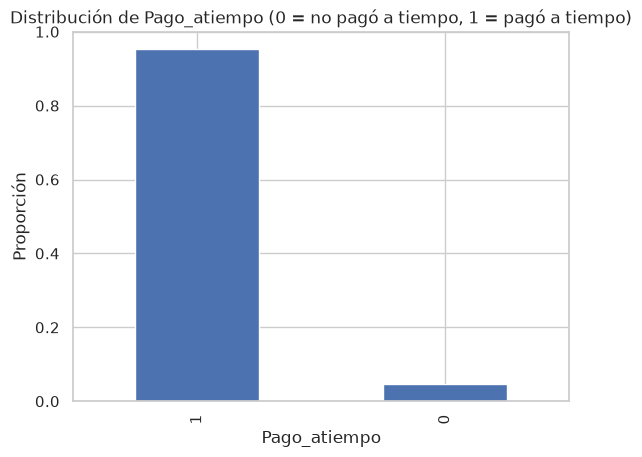

Pago_atiempo
1    0.952523
0    0.047477
Name: proportion, dtype: float64


In [28]:
# Distribución de la variable objetivo
df[target].value_counts(normalize=True).plot(kind="bar")
plt.title("Distribución de Pago_atiempo (0 = no pagó a tiempo, 1 = pagó a tiempo)")
plt.ylabel("Proporción")
plt.show()

print(df[target].value_counts(normalize=True))

**Nota importante:** si la clase minoritaria (mora / no pago a tiempo) representa una fracción pequeña del total, esto es un dataset **desbalanceado**. Esto afecta directamente qué métricas usar en el Avance 2 (accuracy no será suficiente; priorizar recall/F1/ROC-AUC de la clase minoritaria).

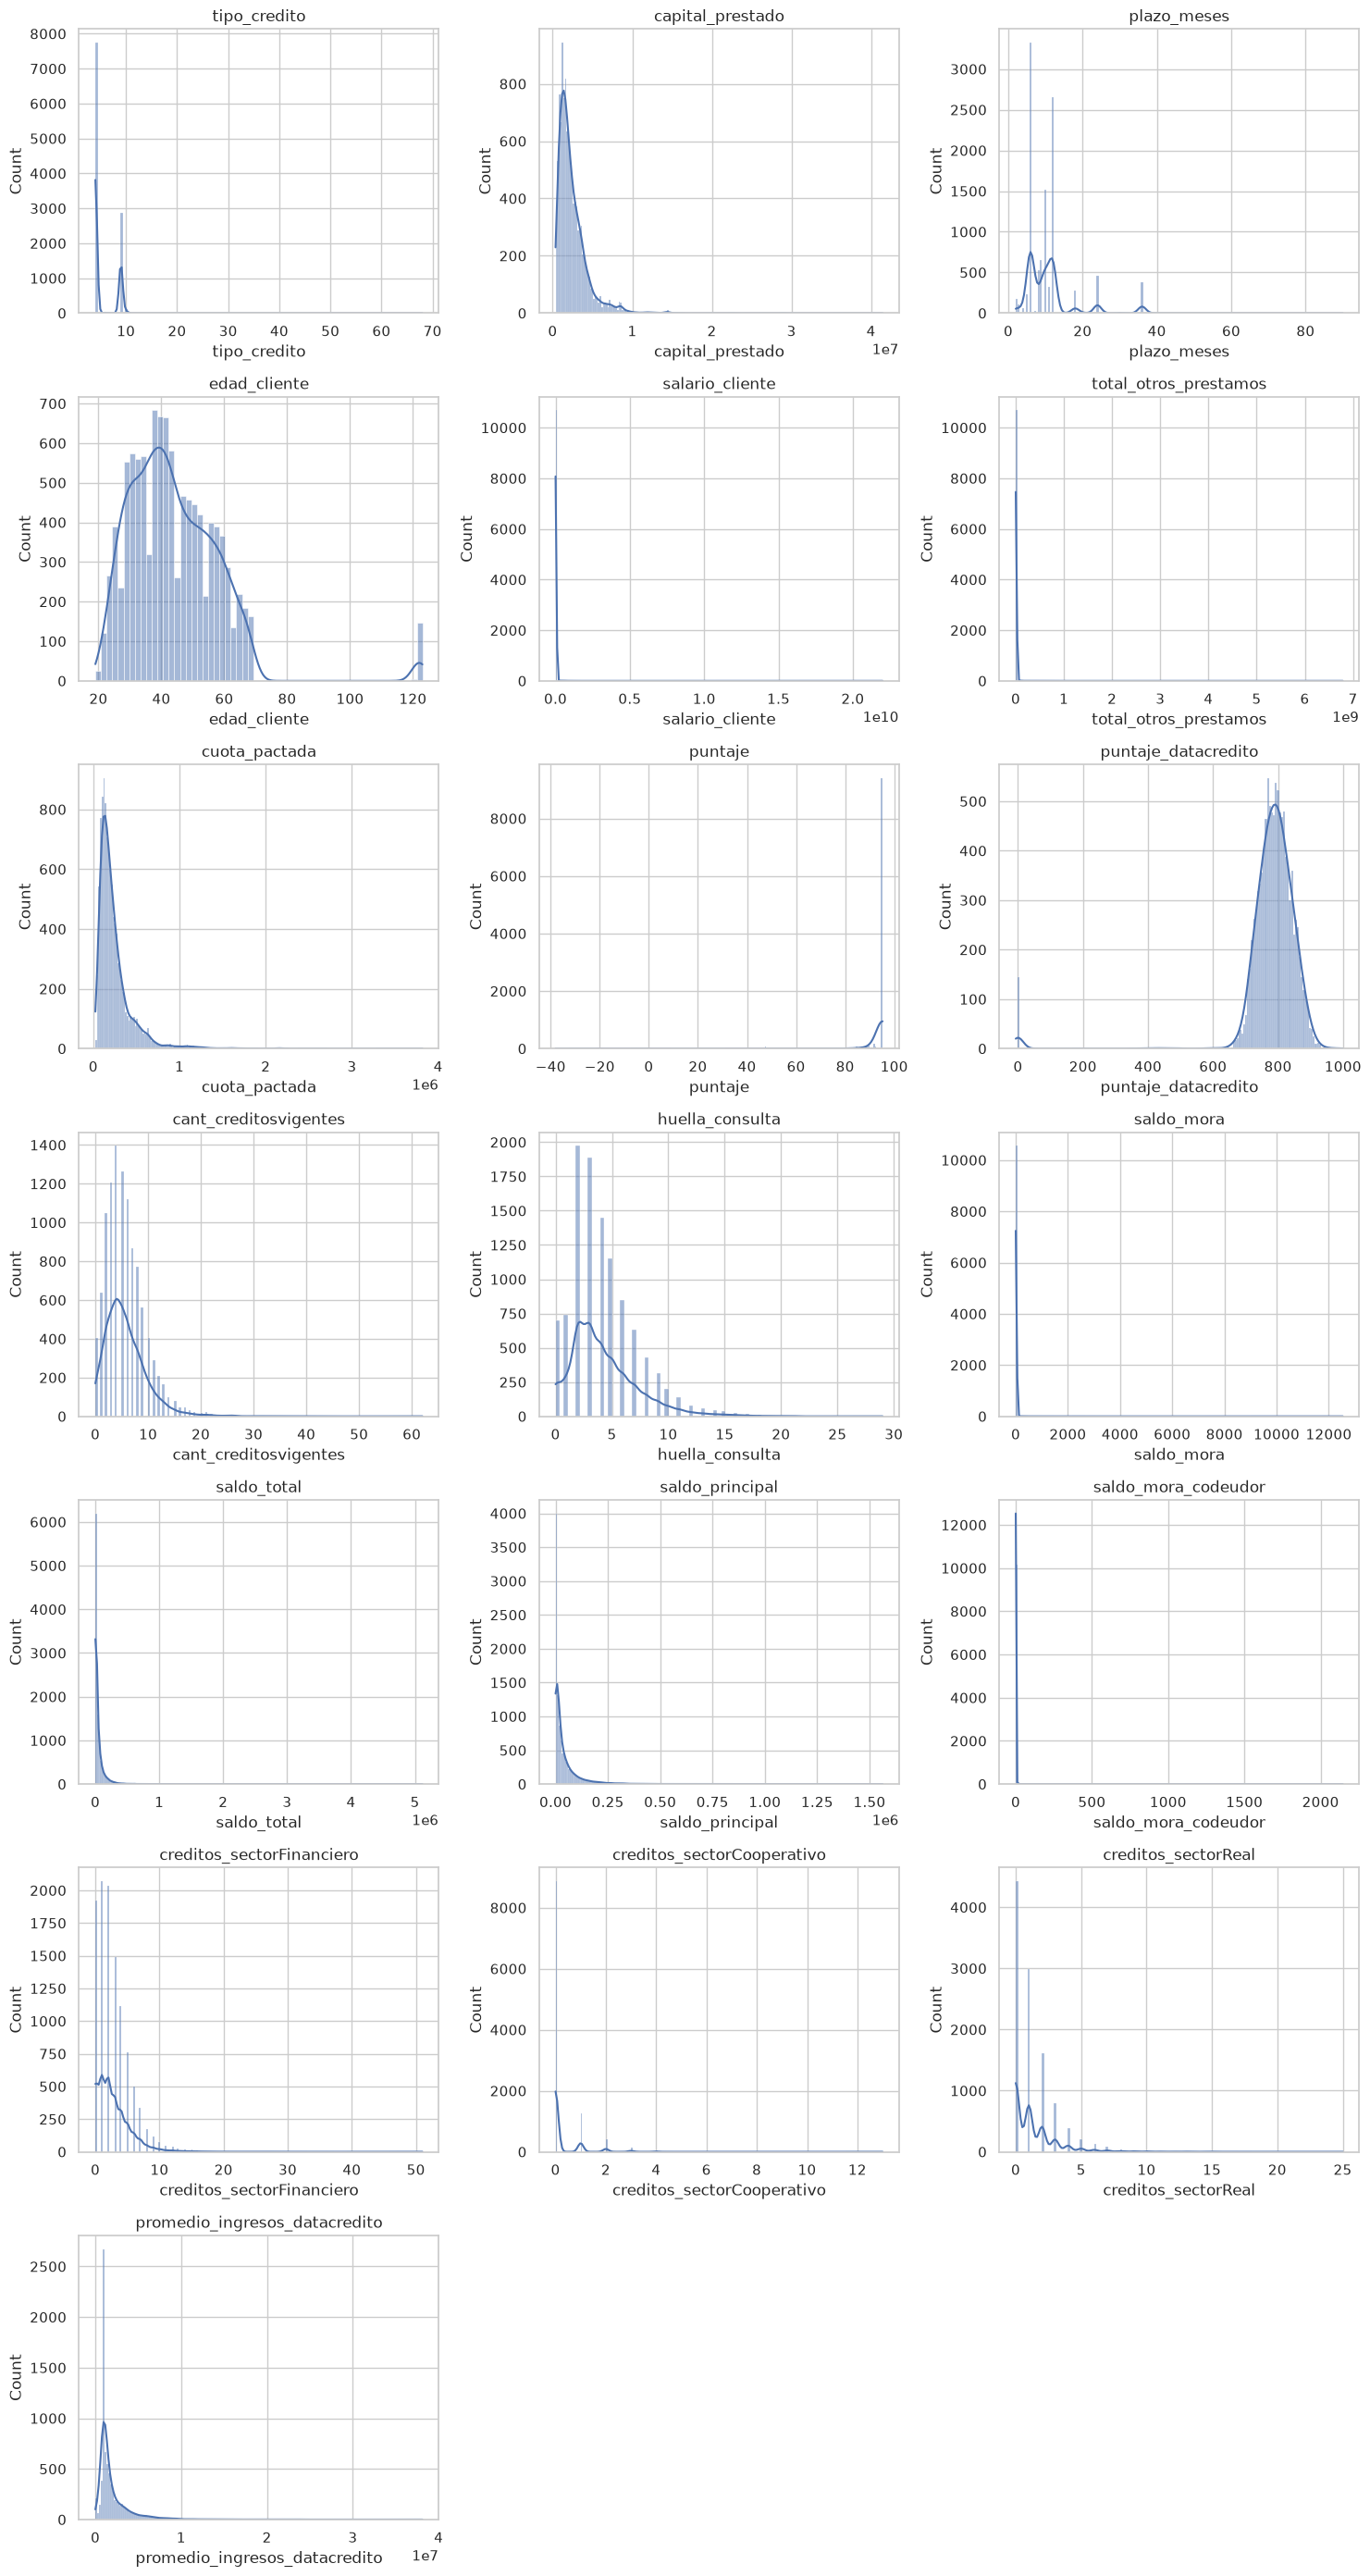

In [29]:
# Distribución de variables numéricas
n = len(col_numericas)
fig, axes = plt.subplots(nrows=(n // 3) + 1, ncols=3, figsize=(15, 4 * ((n // 3) + 1)))
axes = axes.flatten()

for i, col in enumerate(col_numericas):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

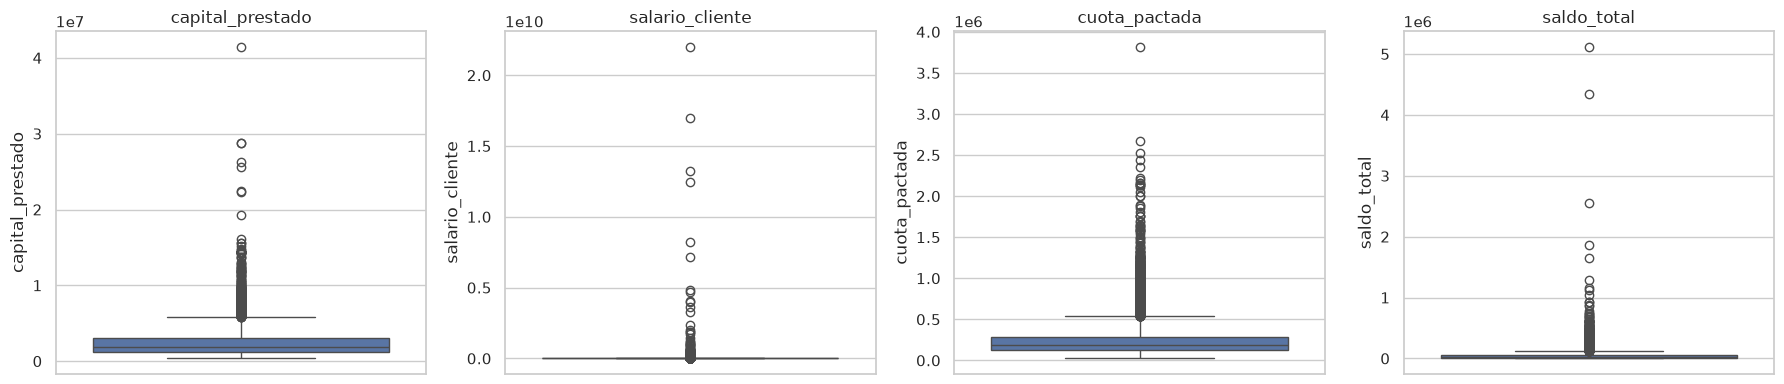

In [30]:
# Boxplots para detectar outliers en variables numéricas clave
cols_revisar = ["capital_prestado", "salario_cliente", "cuota_pactada", "saldo_total"]

fig, axes = plt.subplots(1, len(cols_revisar), figsize=(18, 4))
for ax, col in zip(axes, cols_revisar):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

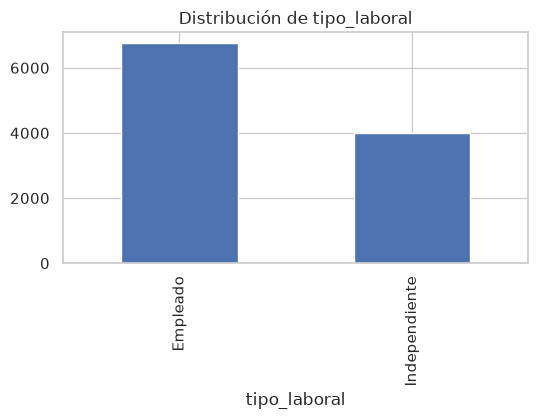

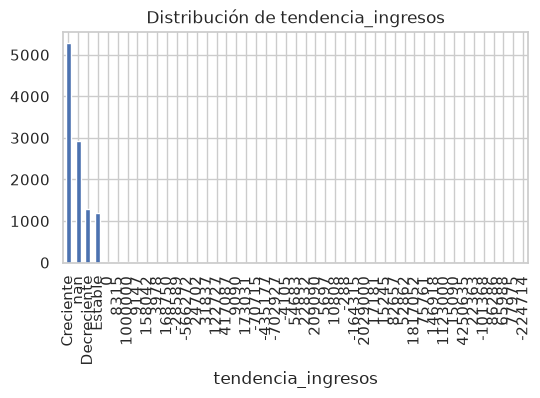

In [31]:
# Distribución de variables categóricas
for col in col_categoricas:
    plt.figure(figsize=(6, 3))
    df[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.show()

### Calidad de datos detectada

Al revisar `tendencia_ingresos` es posible encontrar valores que no corresponden a las categorías esperadas (`Creciente`, `Decreciente`, `Estable`), sino números sueltos. Esto sugiere un error de carga/formato en la fuente original. Este hallazgo debe documentarse y resolverse antes de Feature Engineering (Avance 2): decidir si esos valores son un error de mapeo, o si deben tratarse como nulos.

In [32]:
# Revisar valores inesperados en tendencia_ingresos
categorias_esperadas = ["Creciente", "Decreciente", "Estable"]
valores_raros = df.loc[~df["tendencia_ingresos"].isin(categorias_esperadas), "tendencia_ingresos"]
print("Cantidad de valores fuera de lo esperado:", valores_raros.notna().sum())
valores_raros.dropna().head(10)

Cantidad de valores fuera de lo esperado: 58


157        8315
168           0
440      158042
486        3978
705        9147
1185       8315
1188     168750
1898     -28589
2027       8315
2038    1000000
Name: tendencia_ingresos, dtype: object

## 3. Análisis bivariable (vs. variable objetivo)

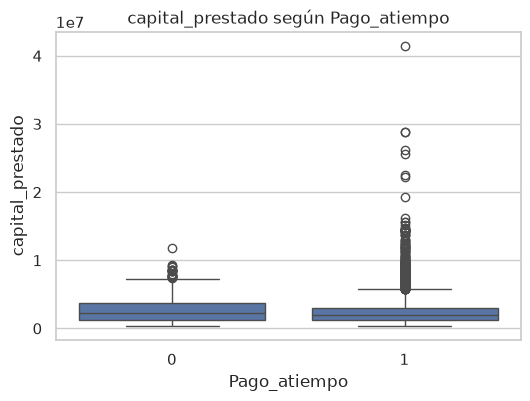

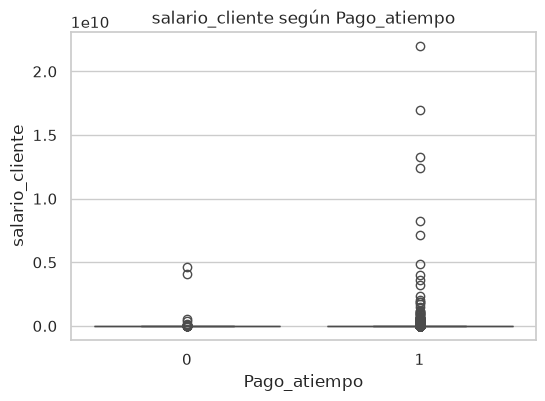

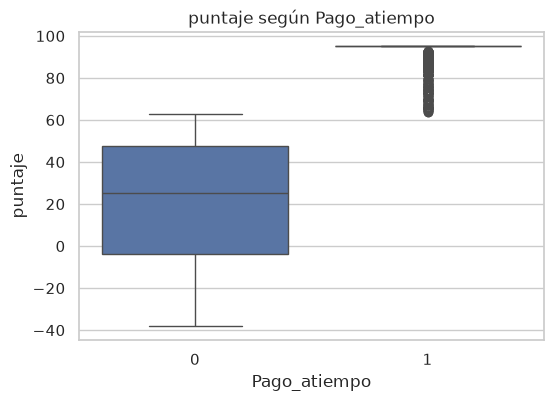

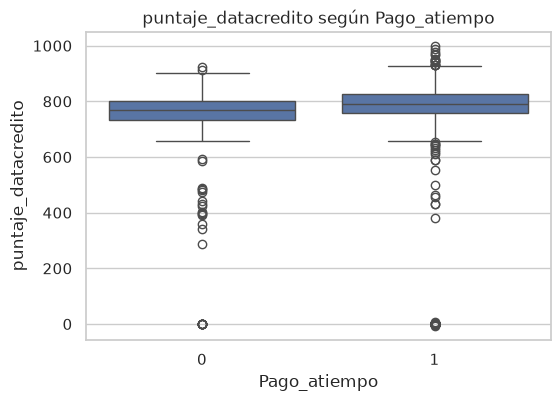

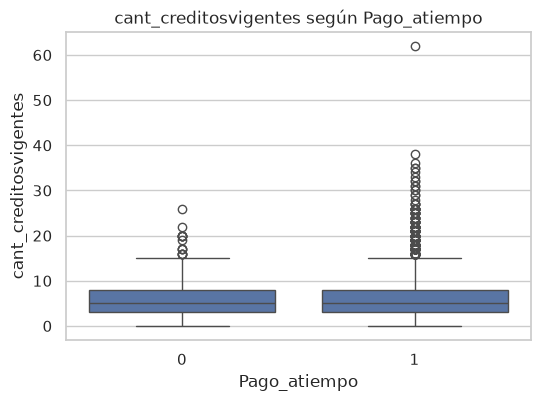

In [33]:
# Numéricas vs target: boxplot comparando distribución según Pago_atiempo
for col in ["capital_prestado", "salario_cliente", "puntaje", "puntaje_datacredito", "cant_creditosvigentes"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f"{col} según {target}")
    plt.show()

In [34]:
# Categóricas vs target: tasa de pago a tiempo por categoría
for col in col_categoricas:
    tabla = pd.crosstab(df[col], df[target], normalize="index")
    print(f"--- {col} ---")
    print(tabla)
    print()

--- tipo_laboral ---
Pago_atiempo          0         1
tipo_laboral                     
Empleado       0.042938  0.957062
Independiente  0.055126  0.944874

--- tendencia_ingresos ---
Pago_atiempo               0         1
tendencia_ingresos                    
-702927             0.000000  1.000000
-566272             0.000000  1.000000
-435177             0.000000  1.000000
-224714             0.000000  1.000000
-164315             0.000000  1.000000
-101368             0.000000  1.000000
-70715              0.000000  1.000000
-28589              0.000000  1.000000
-4105               0.000000  1.000000
-288                0.000000  1.000000
0                   0.000000  1.000000
3978                0.000000  1.000000
5697                0.000000  1.000000
8315                0.000000  1.000000
9090                0.000000  1.000000
9147                0.000000  1.000000
10808               0.000000  1.000000
15090               0.000000  1.000000
15245               0.000000  1.000

In [35]:
# Correlación individual de cada variable numérica con el target
correlaciones_target = df[col_numericas + [target]].corr()[target].sort_values(ascending=False)
correlaciones_target

Pago_atiempo                     1.000000
puntaje                          0.923134
puntaje_datacredito              0.067882
promedio_ingresos_datacredito    0.039867
edad_cliente                     0.032252
creditos_sectorFinanciero        0.021390
creditos_sectorCooperativo       0.021267
saldo_total                      0.014364
saldo_principal                  0.011473
cant_creditosvigentes            0.008829
saldo_mora_codeudor              0.002631
tipo_credito                     0.000951
salario_cliente                 -0.003981
total_otros_prestamos           -0.010041
cuota_pactada                   -0.011814
creditos_sectorReal             -0.023306
capital_prestado                -0.040624
plazo_meses                     -0.063105
saldo_mora                      -0.073458
huella_consulta                 -0.073737
Name: Pago_atiempo, dtype: float64

**A documentar:** ¿qué variables muestran mayor separación entre clientes que pagan a tiempo y los que no? Estas son candidatas fuertes para el modelo (ej. `puntaje`, `puntaje_datacredito`, variables de mora/saldo).

## 4. Análisis multivariable

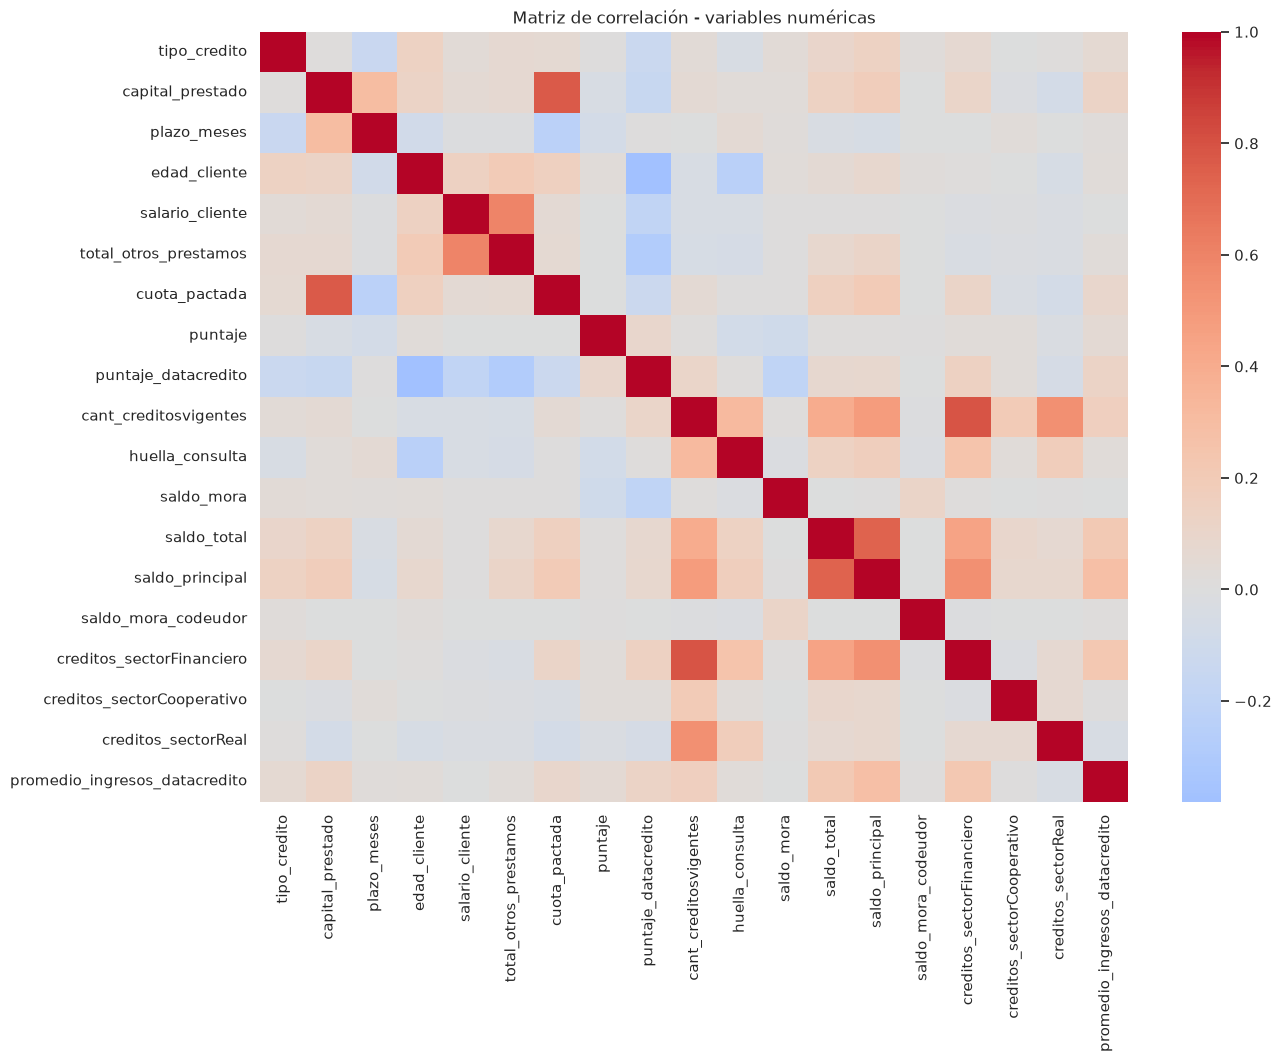

In [36]:
# Matriz de correlación completa
plt.figure(figsize=(14, 10))
corr = df[col_numericas].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación - variables numéricas")
plt.show()

In [37]:
# Pares de variables con correlación fuerte (posible multicolinealidad)
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates()
corr_pairs.head(15)

cant_creditosvigentes          creditos_sectorFinanciero    0.791253
capital_prestado               cuota_pactada                0.764104
saldo_principal                saldo_total                  0.734664
total_otros_prestamos          salario_cliente              0.596990
creditos_sectorReal            cant_creditosvigentes        0.540677
creditos_sectorFinanciero      saldo_principal              0.537307
cant_creditosvigentes          saldo_principal              0.485953
saldo_total                    creditos_sectorFinanciero    0.451957
                               cant_creditosvigentes        0.402105
edad_cliente                   puntaje_datacredito          0.380759
huella_consulta                cant_creditosvigentes        0.317554
capital_prestado               plazo_meses                  0.299781
promedio_ingresos_datacredito  saldo_principal              0.287729
puntaje_datacredito            total_otros_prestamos        0.283266
creditos_sectorFinanciero      hue

In [38]:
# Relación cruzada: tipo_laboral + tendencia_ingresos vs target
pd.crosstab([df["tipo_laboral"], df["tendencia_ingresos"]], df[target], normalize="index")

Pago_atiempo                             0         1
tipo_laboral  tendencia_ingresos                    
Empleado      -702927             0.000000  1.000000
              -566272             0.000000  1.000000
              -435177             0.000000  1.000000
              -164315             0.000000  1.000000
              -101368             0.000000  1.000000
              -70715              0.000000  1.000000
              -28589              0.000000  1.000000
              -4105               0.000000  1.000000
              -288                0.000000  1.000000
              0                   0.000000  1.000000
              5697                0.000000  1.000000
              8315                0.000000  1.000000
              9090                0.000000  1.000000
              9147                0.000000  1.000000
              10808               0.000000  1.000000
              15090               0.000000  1.000000
              15245               0.000000  1.000000
              17181               0.000000  1.000000
              22832               0.000000  1.000000
              31837               0.000000  1.000000
              52862               0.000000  1.000000
              54683               0.000000  1.000000
              75761               0.000000  1.000000
              77975               0.000000  1.000000
              82657               0.000000  1.000000
              86286               0.000000  1.000000
              122727              0.000000  1.000000
              146918              0.000000  1.000000
              158042              0.000000  1.000000
              168750              0.000000  1.000000
              209090              0.000000  1.000000
              417087              0.000000  1.000000
              1000000             0.000000  1.000000
              1123000             0.000000  1.000000
              2029000             0.000000  1.000000
              4250635             0.000000  1.000000
              Creciente           0.035649  0.964351
              Decreciente         0.058698  0.941302
              Estable             0.044892  0.955108
Independiente -224714             0.000000  1.000000
              0                   0.000000  1.000000
              3978                0.000000  1.000000
              8315                0.000000  1.000000
              9147                0.000000  1.000000
              22363               0.000000  1.000000
              24702               0.000000  1.000000
              65988               0.000000  1.000000
              173031              0.000000  1.000000
              1000000             0.000000  1.000000
              1817052             0.000000  1.000000
              Creciente           0.048243  0.951757
              Decreciente         0.073446  0.926554
              Estable             0.047970  0.952030

## 5. Conclusiones del EDA

_Completar con tus propias observaciones antes de entregar. Guía de puntos a cubrir:_

1. Tamaño y calidad general del dataset (nulos, duplicados, inconsistencias como la de `tendencia_ingresos`).
2. Balance de la variable objetivo y su implicación para las métricas del Avance 2.
3. Variables numéricas con mayor poder de separación entre clases (según boxplots y correlación con el target).
4. Variables categóricas relevantes (`tipo_laboral`, `tendencia_ingresos`) y cómo se relacionan con el pago a tiempo.
5. Variables candidatas a eliminar o transformar por alta colinealidad, antes de pasar a Feature Engineering.